Beijing Air Quality — Análisis Exploratorio de Datos (EDA)
Dataset: UCI PRSA 2013-2017  +  Open-Meteo 2022-2026
Universidad La Salle Arequipa — Ciencia de Datos

CELDA 1 — Configuración de rutas locales del dataset

In [1]:
# Rutas locales al dataset (relativas al directorio del notebook)
# Ajusta NOTEBOOK_DIR si ejecutas desde otra ubicación
from pathlib import Path
NOTEBOOK_DIR = Path().resolve()
print(f'Directorio de trabajo: {NOTEBOOK_DIR}')


Directorio de trabajo: C:\dev\beijing-air-quality\notebook


CELDA 2 — Imports y configuración global  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)

# ── Rutas en Drive ────────────────────────────────────────────────
BASE_HIST = Path("../datasets/2013-2017/PRSA_Data_20130301-20170228")
BASE_CURR = Path("../datasets/2022-2026")

# ── Constantes del dominio ────────────────────────────────────────
STATION_COORDS = {
    "Aotizhongxin":  (39.9821, 116.3937),
    "Changping":     (40.2181, 116.2318),
    "Dingling":      (40.2906, 116.2207),
    "Dongsi":        (39.9292, 116.4177),
    "Guanyuan":      (39.9406, 116.3626),
    "Gucheng":       (39.9147, 116.1861),
    "Huairou":       (40.3241, 116.6374),
    "Nongzhanguan":  (39.9372, 116.4474),
    "Shunyi":        (40.1302, 116.6544),
    "Tiantan":       (39.8822, 116.4117),
    "Wanliu":        (39.9561, 116.2984),
    "Wanshouxigong": (39.8661, 116.3668),
}
ZONA_MAP = {
    "Dingling":"Norte",    "Changping":"Norte",  "Huairou":"Norte",
    "Shunyi":"Norte",      "Aotizhongxin":"Centro","Guanyuan":"Centro",
    "Dongsi":"Centro",     "Nongzhanguan":"Centro","Wanliu":"Centro",
    "Gucheng":"Oeste",     "Tiantan":"Sur",      "Wanshouxigong":"Sur",
}
SEASON_MAP = {12:"Invierno",1:"Invierno",2:"Invierno",
              3:"Primavera",4:"Primavera",5:"Primavera",
              6:"Verano",7:"Verano",8:"Verano",
              9:"Otoño",10:"Otoño",11:"Otoño"}
FEATURES_NUM = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEW","WSPM"]
PM25_THRESHOLDS = [
    (0,   35,  "Bueno",                "#2ECC71"),
    (35,  75,  "Moderado",             "#F1C40F"),
    (75,  115, "Insalubre sensibles",  "#E67E22"),
    (115, 150, "Insalubre",            "#E74C3C"),
    (150, 250, "Muy insalubre",        "#8E44AD"),
    (250, 999, "Peligroso",            "#641E16"),
]

# ── Paletas y estilo ──────────────────────────────────────────────
PAL_SEASON  = {"Invierno":"#5B9BD5","Primavera":"#70AD47",
               "Verano":"#FFC000","Otoño":"#ED7D31"}
CRIT_COLOR, MOD_COLOR, OK_COLOR = "#C00000","#FFC000","#70AD47"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8F9FA",
    "axes.grid": True, "grid.alpha": 0.35,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
})

def pm25_cat(val):
    for lo, hi, cat, _ in PM25_THRESHOLDS:
        if lo <= val < hi:
            return cat
    return "Peligroso"

def pm25_color(val):
    for lo, hi, _, color in PM25_THRESHOLDS:
        if lo <= val < hi:
            return color
    return "#641E16"

print("✓ Librerías y constantes cargadas.")
print(f"  Drive histórico : {BASE_HIST}")
print(f"  Drive actual    : {BASE_CURR}")

✓ Librerías y constantes cargadas.
  Drive histórico : ..\datasets\2013-2017\PRSA_Data_20130301-20170228
  Drive actual    : ..\datasets\2022-2026


CELDA 3 — ETL: Carga del dataset histórico 2013-2017   

In [3]:

def load_historical(base: Path) -> pd.DataFrame:
    csv_files = sorted(base.rglob("*.csv"))
    print(f"  Archivos encontrados en {base}: {len(csv_files)}")
    dfs = []
    for p in csv_files:
        try:
            df = pd.read_csv(p, low_memory=False)

            # Detectar estación por nombre de archivo
            station = next((s for s in STATION_COORDS if s.lower() in p.name.lower()), None)
            if station is None:
                station = df["station"].iloc[0] if "station" in df.columns else p.stem

            # Datetime
            if all(c in df.columns for c in ["year","month","day","hour"]):
                df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]], errors="coerce")
            elif "date" in df.columns:
                df["datetime"] = pd.to_datetime(df["date"], errors="coerce")
            else:
                continue

            df["region"] = station
            lat, lon = STATION_COORDS.get(station, (39.9075, 116.3972))
            df["lat"], df["lon"] = lat, lon
            df["period"] = "2013-2017"

            # Renombrar DEWP → DEW (nombre interno estándar)
            if "DEWP" in df.columns and "DEW" not in df.columns:
                df = df.rename(columns={"DEWP": "DEW"})

            for col in FEATURES_NUM:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
                    if col in ("PM2.5","PM10","SO2","NO2","CO","O3"):
                        df.loc[df[col] < 0, col] = np.nan
            dfs.append(df)
        except Exception as e:
            print(f"    ⚠ {p.name}: {e}")

    if not dfs:
        raise FileNotFoundError(f"No se encontraron CSVs válidos en {base}")

    out = pd.concat(dfs, ignore_index=True).sort_values("datetime")
    out["month"]  = out["datetime"].dt.month
    out["hour"]   = out["datetime"].dt.hour
    out["year"]   = out["datetime"].dt.year
    out["season"] = out["month"].map(SEASON_MAP)
    out["date"]   = out["datetime"].dt.date
    out["zona"]   = out["region"].map(ZONA_MAP).fillna("Centro")

    # Interpolación lineal PM2.5 por estación
    out = out.sort_values(["region","datetime"])
    out["PM2.5"] = out.groupby("region")["PM2.5"].transform(
        lambda x: x.interpolate("linear").clip(lower=0))

    print(f"  ✓ Registros   : {len(out):,}")
    print(f"  ✓ Estaciones  : {out['region'].nunique()}: {sorted(out['region'].unique())}")
    print(f"  ✓ Rango       : {out['datetime'].min().date()} → {out['datetime'].max().date()}")
    print(f"  ✓ PM2.5 media : {out['PM2.5'].mean():.2f} µg/m³")
    return out

print("Cargando dataset histórico 2013-2017 …")
df_hist = load_historical(BASE_HIST)

Cargando dataset histórico 2013-2017 …
  Archivos encontrados en ..\datasets\2013-2017\PRSA_Data_20130301-20170228: 12
  ✓ Registros   : 420,768
  ✓ Estaciones  : 12: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
  ✓ Rango       : 2013-03-01 → 2017-02-28
  ✓ PM2.5 media : 79.84 µg/m³


CELDA 4 — ETL: Carga del dataset actual 2022-2026

In [4]:
def load_current(base: Path) -> pd.DataFrame:
    csv_files = sorted(base.rglob("*.csv"))
    print(f"  Archivos encontrados en {base}: {len(csv_files)}")
    dfs = []
    for p in csv_files:
        try:
            df = pd.read_csv(p, low_memory=False)
            rename = {
                "pm2_5":"PM2.5","pm10":"PM10","so2":"SO2","no2":"NO2",
                "co":"CO","o3":"O3","ozone":"O3",
                "temperature_2m":"TEMP","surface_pressure":"PRES",
                "dewpoint_2m":"DEW","windspeed_10m":"WSPM",
                "precipitation":"RAIN","winddirection_10m":"wd",
            }
            df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})

            date_col = next((c for c in ["datetime","date","time","timestamp"]
                             if c in df.columns), None)
            if date_col is None: continue
            df["datetime"] = pd.to_datetime(df[date_col], errors="coerce")
            if "region" not in df.columns:
                df["region"] = "Beijing"
            df["lat"] = df.get("lat", 39.9075)
            df["lon"] = df.get("lon", 116.3972)
            df["period"] = "2022-2026"

            if "PM2.5" in df.columns:
                df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce").clip(lower=0)
            for col in ["PM10","TEMP","PRES","DEW","WSPM","SO2","NO2","CO","O3"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            dfs.append(df)
        except Exception as e:
            print(f"    ⚠ {p.name}: {e}")

    if not dfs:
        raise FileNotFoundError(f"No se encontraron CSVs válidos en {base}")

    out = pd.concat(dfs, ignore_index=True).dropna(subset=["PM2.5","datetime"])
    out = out.sort_values("datetime").reset_index(drop=True)
    out["month"]  = out["datetime"].dt.month
    out["hour"]   = out["datetime"].dt.hour
    out["year"]   = out["datetime"].dt.year
    out["season"] = out["month"].map(SEASON_MAP)
    out["date"]   = out["datetime"].dt.date

    print(f"  ✓ Registros   : {len(out):,}")
    print(f"  ✓ Zonas       : {sorted(out['region'].unique())}")
    print(f"  ✓ Rango       : {out['datetime'].min().date()} → {out['datetime'].max().date()}")
    print(f"  ✓ PM2.5 media : {out['PM2.5'].mean():.2f} µg/m³")
    return out

print("Cargando dataset actual 2022-2026 …")
df_curr = load_current(BASE_CURR)

Cargando dataset actual 2022-2026 …
  Archivos encontrados en ..\datasets\2022-2026: 3
  ✓ Registros   : 1,294
  ✓ Zonas       : ['Beijing']
  ✓ Rango       : 2022-08-04 → 2026-02-17
  ✓ PM2.5 media : 78.88 µg/m³


CELDA 5 — Estadísticas descriptivas comparadas

In [5]:
def resumen(df, label):
    pm = df["PM2.5"].dropna()
    return {
        "Período": label,
        "Registros": f"{len(df):,}",
        "PM2.5 media": f"{pm.mean():.2f} µg/m³",
        "PM2.5 std":   f"{pm.std():.2f}",
        "PM2.5 p50":   f"{pm.median():.2f}",
        "PM2.5 p95":   f"{pm.quantile(0.95):.2f}",
        "PM2.5 max":   f"{pm.max():.2f}",
        "% críticos (>150)": f"{(pm>150).mean()*100:.2f}%",
    }

tabla_res = pd.DataFrame([resumen(df_hist,"2013-2017"), resumen(df_curr,"2022-2026")]).set_index("Período")
print("═"*55)
print("  RESUMEN COMPARADO — Ambos períodos")
print("═"*55)
display(tabla_res.T)

mejora_media = (df_hist["PM2.5"].mean() - df_curr["PM2.5"].mean()) / df_hist["PM2.5"].mean() * 100
mejora_crit  = (df_hist["PM2.5"]>150).mean()*100 - (df_curr["PM2.5"]>150).mean()*100
print(f"\n  Mejora media PM2.5  : {'↓' if mejora_media>0 else '↑'}{abs(mejora_media):.1f}%")
print(f"  Mejora días críticos: {'↓' if mejora_crit>0 else '↑'}{abs(mejora_crit):.1f} pp")

═══════════════════════════════════════════════════════
  RESUMEN COMPARADO — Ambos períodos
═══════════════════════════════════════════════════════


Período,2013-2017,2022-2026
Registros,"420,768","1,294"
PM2.5 media,79.84 µg/m³,78.88 µg/m³
PM2.5 std,80.95,47.12
PM2.5 p50,55.00,68.63
PM2.5 p95,242.00,175.94
PM2.5 max,999.00,295.98
% críticos (>150),15.18%,9.12%



  Mejora media PM2.5  : ↓1.2%
  Mejora días críticos: ↓6.1 pp


GRÁFICO 1 — Boxplot PM2.5 por estación + % días críticos

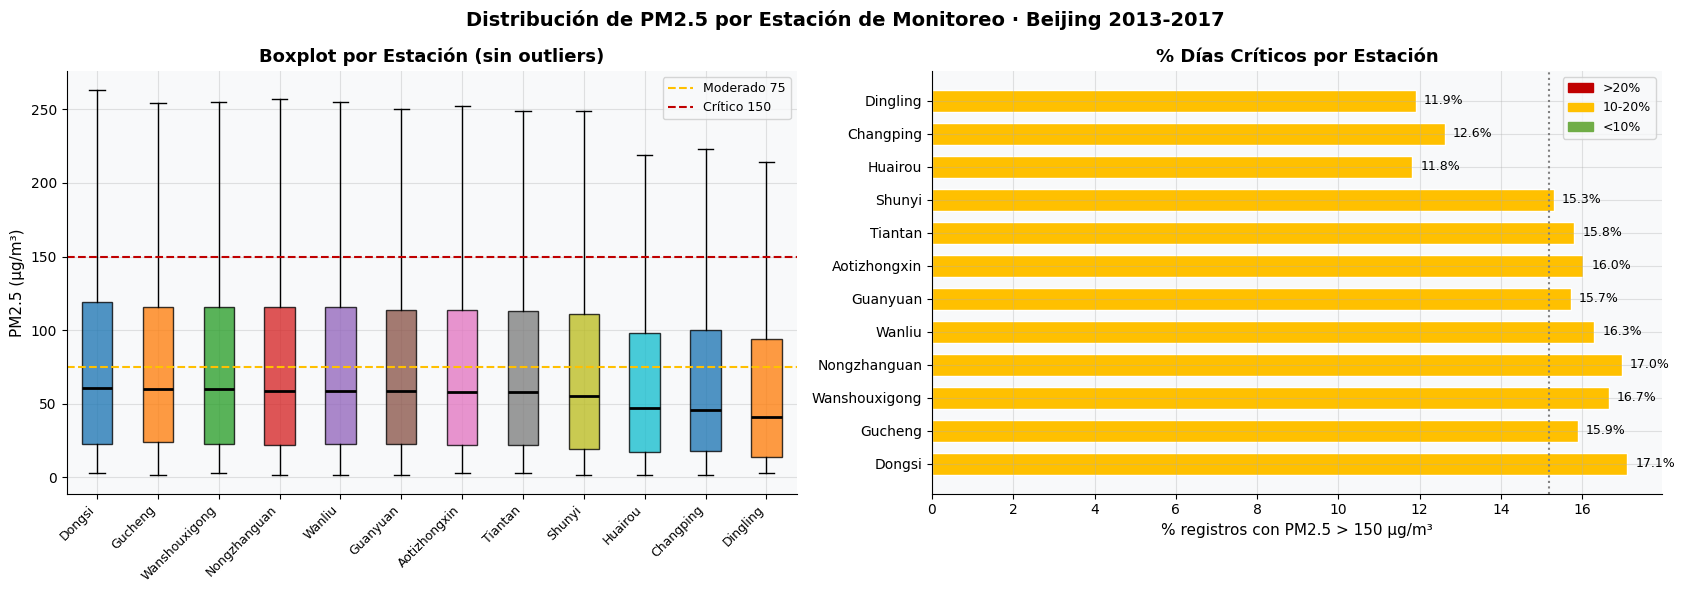

✓ Guardado: grafico1_boxplot_estaciones.png


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Distribución de PM2.5 por Estación de Monitoreo · Beijing 2013-2017",
             fontsize=14, fontweight="bold")

order = df_hist.groupby("region")["PM2.5"].median().sort_values(ascending=False).index.tolist()
pal   = sns.color_palette("tab10", len(order))

# Panel A: Boxplot
bp_data = [df_hist[df_hist["region"]==s]["PM2.5"].dropna().values for s in order]
bp = axes[0].boxplot(bp_data, patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", lw=2))
for patch, c in zip(bp["boxes"], pal):
    patch.set_facecolor(c); patch.set_alpha(0.78)
axes[0].set_xticklabels(order, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("PM2.5 (µg/m³)"); axes[0].set_title("Boxplot por Estación (sin outliers)")
axes[0].axhline(75,  color=MOD_COLOR,  ls="--", lw=1.5, label="Moderado 75")
axes[0].axhline(150, color=CRIT_COLOR, ls="--", lw=1.5, label="Crítico 150")
axes[0].legend(fontsize=9)

# Panel B: % días críticos horizontal
pct = (df_hist.groupby("region")["PM2.5"]
       .apply(lambda x: (x>150).mean()*100)
       .reindex(order))
colors_b = [CRIT_COLOR if v>20 else MOD_COLOR if v>10 else OK_COLOR for v in pct]
bars = axes[1].barh(order, pct.values, color=colors_b, edgecolor="white", height=0.65)
axes[1].axvline(pct.mean(), color="gray", ls=":", lw=1.5, label=f"Media {pct.mean():.1f}%")
for bar, val in zip(bars, pct.values):
    axes[1].text(val+0.2, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_xlabel("% registros con PM2.5 > 150 µg/m³")
axes[1].set_title("% Días Críticos por Estación")
patches = [mpatches.Patch(color=CRIT_COLOR,label=">20%"),
           mpatches.Patch(color=MOD_COLOR, label="10-20%"),
           mpatches.Patch(color=OK_COLOR,  label="<10%")]
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig("grafico1_boxplot_estaciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico1_boxplot_estaciones.png")

GRÁFICO 2 — Serie temporal mensual: ambos períodos

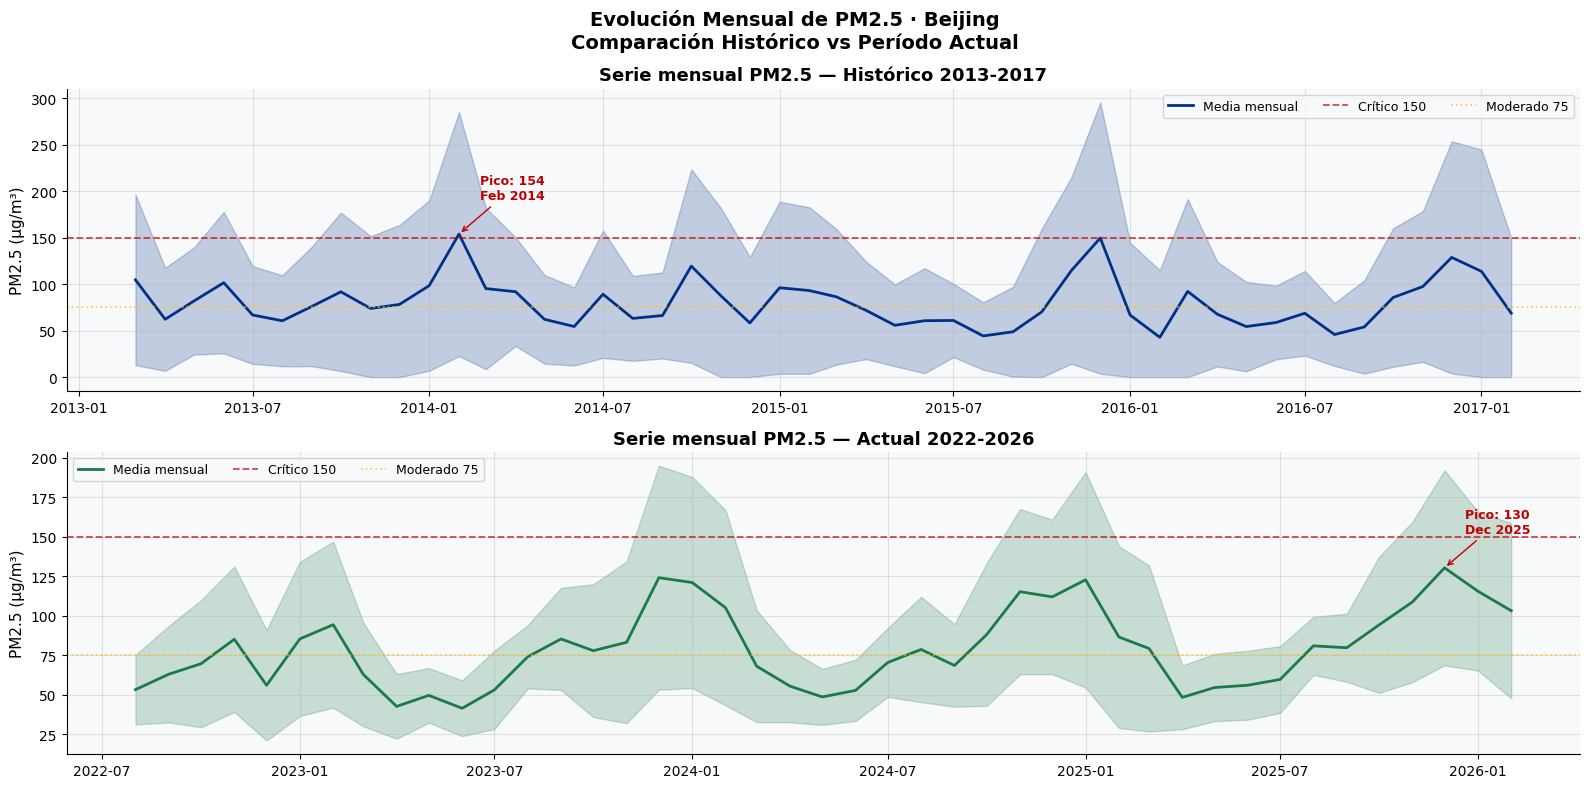

✓ Guardado: grafico2_serie_temporal_ambos.png


In [10]:

def monthly_agg(df):
    g = df.groupby(df["datetime"].dt.to_period("M"))["PM2.5"].agg(["mean","std"]).reset_index()
    g["datetime"] = g["datetime"].dt.to_timestamp()
    g["lo"] = (g["mean"] - g["std"]).clip(lower=0)
    g["hi"] =  g["mean"] + g["std"]
    return g

mh = monthly_agg(df_hist)
mc = monthly_agg(df_curr)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, mg, label, color, period in [
    (axes[0], mh, "Histórico 2013-2017", "#003087", "hist"),
    (axes[1], mc, "Actual 2022-2026",    "#1A7A4A", "curr"),
]:
    ax.fill_between(mg["datetime"], mg["lo"], mg["hi"], alpha=0.22, color=color)
    ax.plot(mg["datetime"], mg["mean"], color=color, lw=2, label="Media mensual")
    ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.3, alpha=0.7, label="Crítico 150")
    ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.3, alpha=0.7, label="Moderado 75")
    peak = mg.loc[mg["mean"].idxmax()]
    ax.annotate(f"Pico: {peak['mean']:.0f}\n{peak['datetime'].strftime('%b %Y')}",
                xy=(peak["datetime"], peak["mean"]),
                xytext=(15, 25), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=CRIT_COLOR),
                color=CRIT_COLOR, fontsize=9, fontweight="bold")
    ax.set_title(f"Serie mensual PM2.5 — {label}", fontweight="bold")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend(ncol=3, fontsize=9)

fig.suptitle("Evolución Mensual de PM2.5 · Beijing\nComparación Histórico vs Período Actual",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico2_serie_temporal_ambos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico2_serie_temporal_ambos.png")

GRÁFICO 3 — Heatmap hora × mes (histórico)

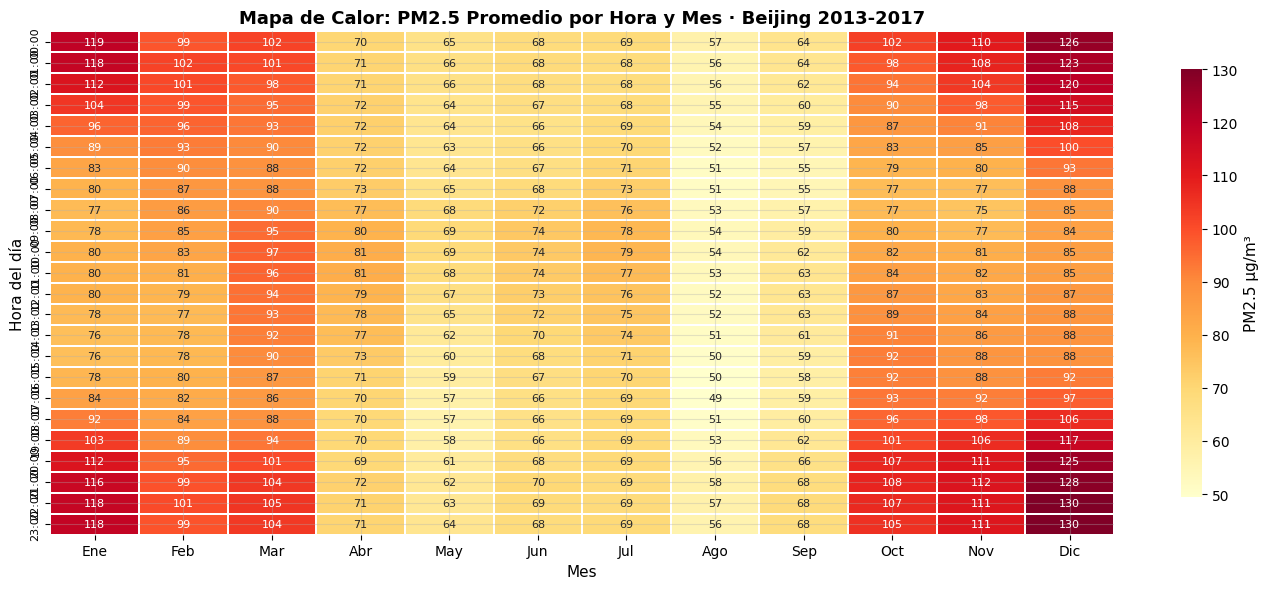

✓ Guardado: grafico3_heatmap_hora_mes.png


In [11]:

pivot_hm = (df_hist.groupby(["hour","month"])["PM2.5"]
              .mean().unstack("month"))
pivot_hm.columns = ["Ene","Feb","Mar","Abr","May","Jun",
                     "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_hm, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label":"PM2.5 µg/m³","shrink":0.85},
            annot=True, fmt=".0f", annot_kws={"size":8})
ax.set_title("Mapa de Calor: PM2.5 Promedio por Hora y Mes · Beijing 2013-2017",
             fontweight="bold")
ax.set_xlabel("Mes"); ax.set_ylabel("Hora del día")
ax.set_yticklabels([f"{h:02d}:00" for h in range(24)], fontsize=8)
plt.tight_layout()
plt.savefig("grafico3_heatmap_hora_mes.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico3_heatmap_hora_mes.png")


GRÁFICO 4 — Violinplot estacional Norte / Centro / Sur  

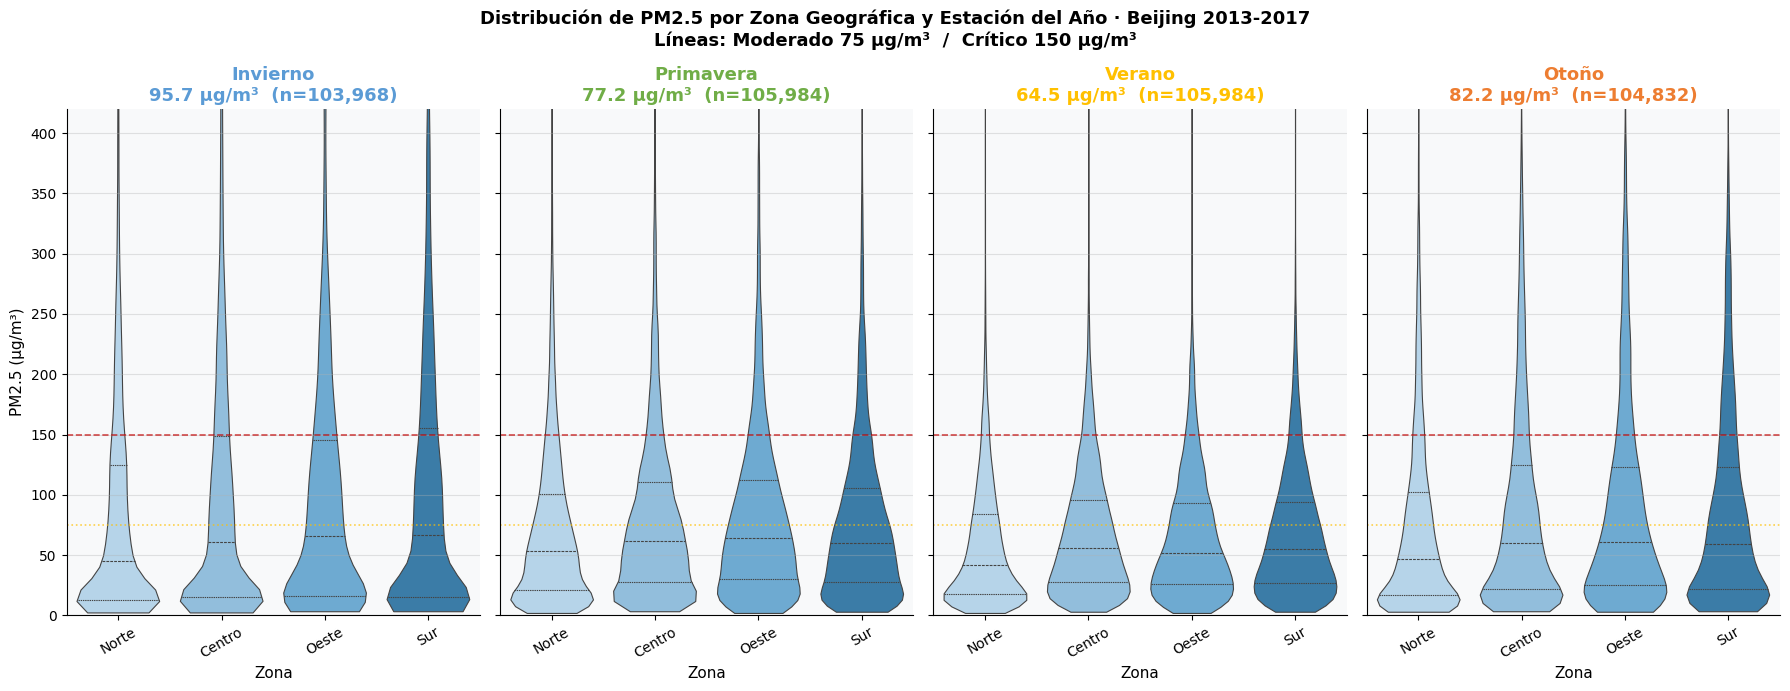

✓ Guardado: grafico4_violinplot_zona_season.png


In [12]:

seasons_order = ["Invierno","Primavera","Verano","Otoño"]
zonas_order   = ["Norte","Centro","Oeste","Sur"]

fig, axes = plt.subplots(1, 4, figsize=(18, 7), sharey=True)
for ax, season in zip(axes, seasons_order):
    sub = df_hist[df_hist["season"] == season]
    sns.violinplot(data=sub, x="zona", y="PM2.5", order=zonas_order,
                   palette=["#AED6F1","#85C1E9","#5DADE2","#2980B9"],
                   inner="quartile", cut=0, ax=ax, linewidth=0.8)
    n = len(sub)
    mean_s = sub["PM2.5"].mean()
    ax.set_title(f"{season}\n{mean_s:.1f} µg/m³  (n={n:,})",
                 fontweight="bold", color=PAL_SEASON[season])
    ax.set_xlabel("Zona"); ax.set_ylabel("PM2.5 (µg/m³)" if ax == axes[0] else "")
    ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.2, alpha=0.7)
    ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.2, alpha=0.7)
    ax.tick_params(axis="x", rotation=30); ax.set_ylim(0, 420)

fig.suptitle("Distribución de PM2.5 por Zona Geográfica y Estación del Año · Beijing 2013-2017\n"
             "Líneas: Moderado 75 µg/m³  /  Crítico 150 µg/m³",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico4_violinplot_zona_season.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico4_violinplot_zona_season.png")

GRÁFICO 5 — Correlación multivariada + scatter viento/PM2.5

In [13]:
# DIAGNÓSTICO — ejecutar si hay KeyError de columnas
print("Columnas disponibles en df_hist:")
print(sorted(df_hist.columns.tolist()))
print("\nPrimeras filas:")
df_hist.head(2)

Columnas disponibles en df_hist:
['CO', 'DEW', 'NO2', 'No', 'O3', 'PM10', 'PM2.5', 'PRES', 'RAIN', 'SO2', 'TEMP', 'WSPM', 'date', 'datetime', 'day', 'hour', 'lat', 'lon', 'month', 'period', 'region', 'season', 'station', 'wd', 'year', 'zona']

Primeras filas:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,WSPM,station,datetime,region,lat,lon,period,season,date,zona
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,...,4.40,Aotizhongxin,2013-03-01 00:00:00,Aotizhongxin,39.98,116.39,2013-2017,Primavera,2013-03-01,Centro
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,...,4.70,Aotizhongxin,2013-03-01 01:00:00,Aotizhongxin,39.98,116.39,2013-2017,Primavera,2013-03-01,Centro


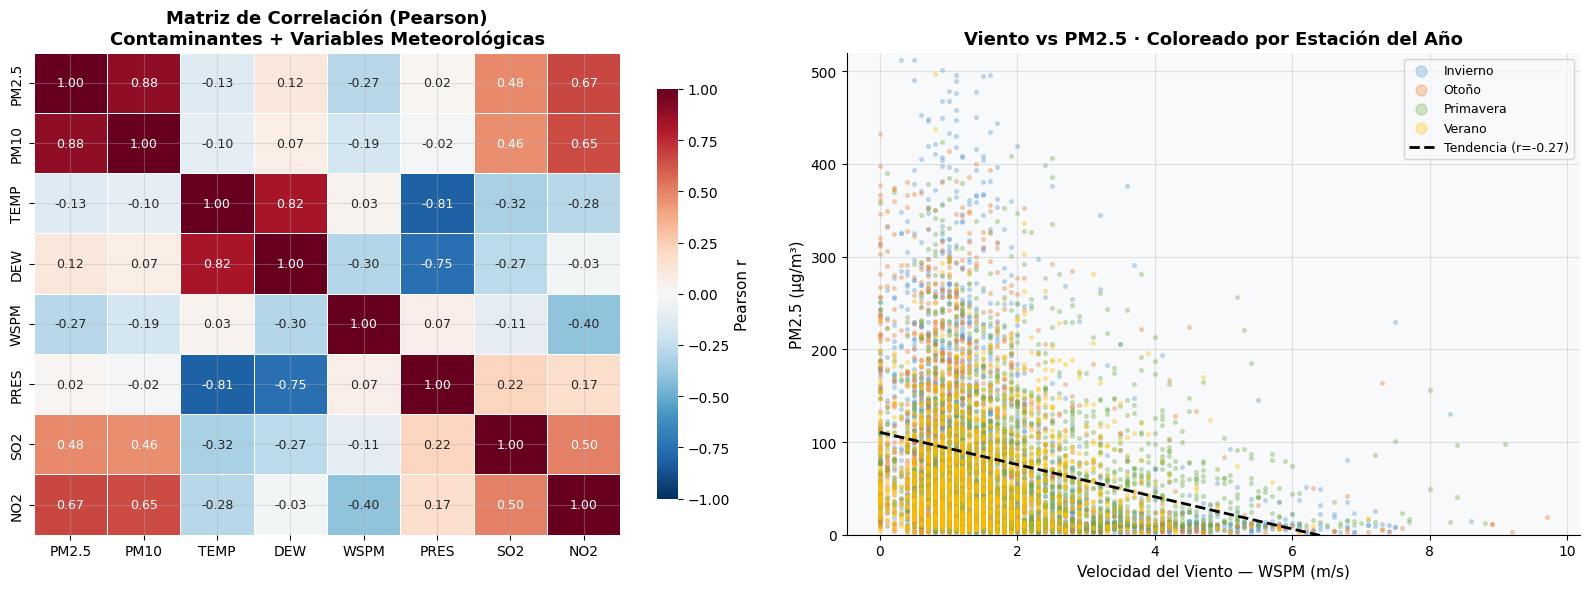

✓ Guardado: grafico5_correlacion_multivariada.png


In [14]:

FEATS_CORR = ["PM2.5","PM10","TEMP","DEW","WSPM","PRES","SO2","NO2"]
sub_corr = df_hist[FEATS_CORR].dropna()
corr_mat = sub_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: heatmap
sns.heatmap(corr_mat, ax=axes[0], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size":9}, linewidths=0.5,
            cbar_kws={"shrink":0.85,"label":"Pearson r"})
axes[0].set_title("Matriz de Correlación (Pearson)\nContaminantes + Variables Meteorológicas",
                  fontweight="bold")

# Panel B: scatter WSPM vs PM2.5 por estación
sample = df_hist[["WSPM","PM2.5","season"]].dropna().sample(n=min(8000,len(df_hist)), random_state=42)
for season, grp in sample.groupby("season"):
    axes[1].scatter(grp["WSPM"], grp["PM2.5"],
                    c=PAL_SEASON[season], alpha=0.3, s=7, label=season, zorder=2)
ws_v, pm_v = sample["WSPM"].values, sample["PM2.5"].values
coef = np.polyfit(ws_v, pm_v, 1)
x_l  = np.linspace(ws_v.min(), ws_v.max(), 200)
r_wp = corr_mat.loc["WSPM","PM2.5"]
axes[1].plot(x_l, np.polyval(coef, x_l), color="black", lw=2, ls="--",
             label=f"Tendencia (r={r_wp:.2f})")
axes[1].set_xlabel("Velocidad del Viento — WSPM (m/s)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Viento vs PM2.5 · Coloreado por Estación del Año", fontweight="bold")
axes[1].set_ylim(0, 520); axes[1].legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig("grafico5_correlacion_multivariada.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico5_correlacion_multivariada.png")

GRÁFICO 6 — KNN Similitud coseno entre estaciones (heatmap)

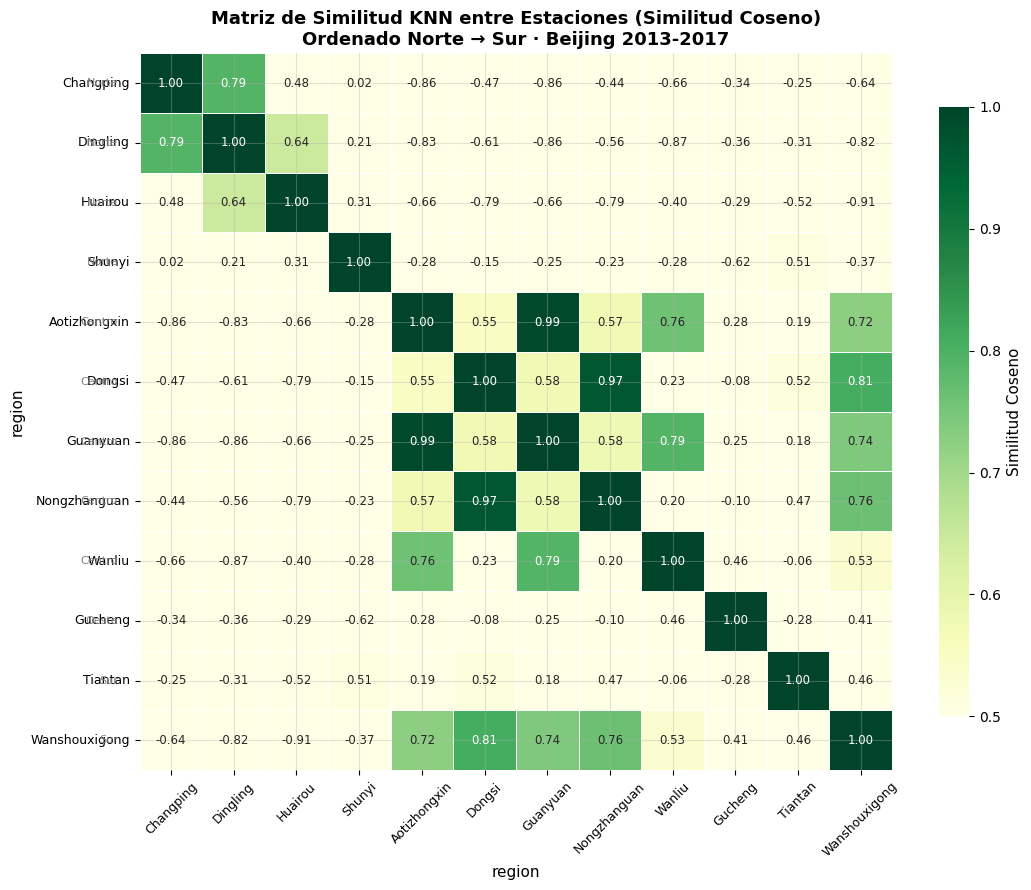

✓ Guardado: grafico6_knn_similitud.png


In [15]:

feats_knn = [f for f in FEATURES_NUM if f in df_hist.columns]
st_means  = df_hist.groupby("region")[feats_knn].mean().dropna(axis=1, thresh=6).fillna(0)

scaler   = StandardScaler()
X_sc     = scaler.fit_transform(st_means)
sim_mat  = cosine_similarity(X_sc)
sim_df   = pd.DataFrame(sim_mat, index=st_means.index, columns=st_means.index)

# Reordenar por zona geográfica (norte → sur)
zona_order = sorted(st_means.index, key=lambda s: ["Norte","Centro","Oeste","Sur"].index(
    ZONA_MAP.get(s,"Centro")))
sim_df = sim_df.reindex(index=zona_order, columns=zona_order)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sim_df, ax=ax, cmap="YlGn", vmin=0.5, vmax=1.0,
            annot=True, fmt=".2f", annot_kws={"size":8.5},
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Similitud Coseno","shrink":0.85})
ax.set_title("Matriz de Similitud KNN entre Estaciones (Similitud Coseno)\n"
             "Ordenado Norte → Sur · Beijing 2013-2017", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

# Etiquetas de zona
for i, st in enumerate(zona_order):
    zona = ZONA_MAP.get(st, "?")
    ax.text(-0.35, i + 0.5, zona, va="center", ha="right",
            fontsize=8, color="gray", transform=ax.transData)

plt.tight_layout()
plt.savefig("grafico6_knn_similitud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico6_knn_similitud.png")

GRÁFICO 7 — Comparativa estacional Histórico vs Actual

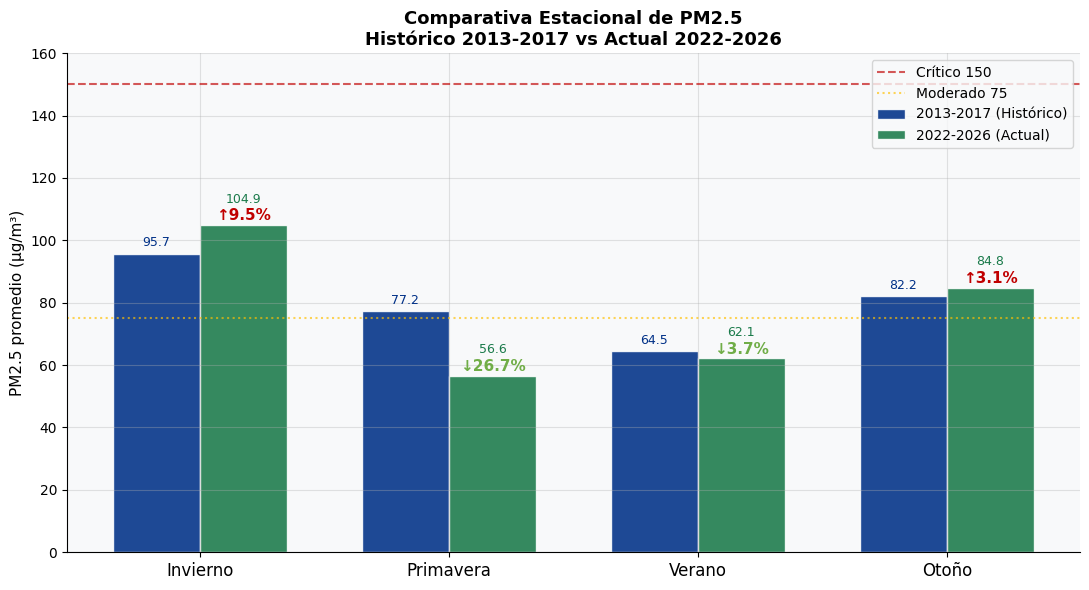

✓ Guardado: grafico7_comparativa_periodos.png


In [ ]:

seasons_order = ["Invierno","Primavera","Verano","Otoño"]
hist_sea = df_hist.groupby("season")["PM2.5"].mean().reindex(seasons_order)
curr_sea = df_curr.groupby("season")["PM2.5"].mean().reindex(seasons_order)

x, w = np.arange(len(seasons_order)), 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, hist_sea.values, w, label="2013-2017 (Histórico)",
            color="#003087", alpha=0.88, edgecolor="white")
b2 = ax.bar(x + w/2, curr_sea.values, w, label="2022-2026 (Actual)",
            color="#1A7A4A", alpha=0.88, edgecolor="white")

for v1, v2, xi in zip(hist_sea.values, curr_sea.values, x):
    if not (np.isnan(v1) or np.isnan(v2)):
        pct  = (v2 - v1) / v1 * 100
        sign = "↑" if pct > 0 else "↓"
        col  = CRIT_COLOR if pct > 0 else OK_COLOR
        ax.text(xi + w/2, v2 + 1.5, f"{sign}{abs(pct):.1f}%",
                ha="center", fontsize=11, color=col, fontweight="bold")

ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9, color="#003087")
ax.bar_label(b2, fmt="%.1f", padding=14, fontsize=9, color="#1A7A4A")

ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.5, alpha=0.65, label="Crítico 150")
ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.5, alpha=0.65, label="Moderado 75")
ax.set_xticks(x); ax.set_xticklabels(seasons_order, fontsize=12)
ax.set_ylabel("PM2.5 promedio (µg/m³)"); ax.set_ylim(0, 160)
ax.set_title("Comparativa Estacional de PM2.5\nHistórico 2013-2017 vs Actual 2022-2026",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("grafico7_comparativa_periodos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico7_comparativa_periodos.png")

## VECTOR DE CARACTERÍSTICAS — Construcción y Preprocesamiento Unificado
### Beijing Air Quality 2013-2026
Este bloque construye el **vector de características unificado** (objeto de estudio),
listo para ingresar a modelos de reducción de dimensionalidad (PCA) o visualización interactiva KNN.

Pasos: ETL unificado → calidad de datos → ingeniería de características → normalización Min-Max → `vector_caracteristicas_unificado`.

#### VC-1 — Imports adicionales para el vector de características

In [6]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print('✓ Imports adicionales cargados.')


✓ Imports adicionales cargados.


#### VC-2 — ETL: Conversión horaria → diaria (sincronización de granularidad)

In [7]:
COLS_DAILY = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
              'TEMP', 'PRES', 'DEW', 'WSPM', 'RAIN']
COLS_DAILY = [c for c in COLS_DAILY if c in df_hist.columns]

def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) else np.nan

agg_dict = {c: 'mean' for c in COLS_DAILY}
if 'wd' in df_hist.columns:
    agg_dict['wd'] = safe_mode

df_hist_daily = (
    df_hist
    .groupby(['region', 'date'])
    .agg(agg_dict)
    .reset_index()
)
df_hist_daily['datetime'] = pd.to_datetime(df_hist_daily['date'])
df_hist_daily['year']   = df_hist_daily['datetime'].dt.year
df_hist_daily['month']  = df_hist_daily['datetime'].dt.month
df_hist_daily['period'] = '2013-2017'
df_hist_daily['zona']   = df_hist_daily['region'].map(ZONA_MAP).fillna('Centro')

print(f'✓ Dataset histórico diario: {len(df_hist_daily):,} registros')
print(f'  Rango: {df_hist_daily["datetime"].min().date()} → {df_hist_daily["datetime"].max().date()}')
print(f'  Columnas: {list(df_hist_daily.columns)}')
df_hist_daily.head(3)


✓ Dataset histórico diario: 17,532 registros
  Rango: 2013-03-01 → 2017-02-28
  Columnas: ['region', 'date', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEW', 'WSPM', 'RAIN', 'wd', 'datetime', 'year', 'month', 'period', 'zona']


,region,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEW,WSPM,RAIN,wd,datetime,year,month,period,zona
0,Aotizhongxin,2013-03-01,7.12,10.75,11.71,22.58,429.17,63.88,1.39,1026.88,-18.75,3.25,0.00,N,2013-03-01,2013,3,2013-2017,Centro
1,Aotizhongxin,2013-03-02,30.75,42.08,36.62,66.67,824.92,29.75,0.62,1026.85,-15.94,1.48,0.00,NE,2013-03-02,2013,3,2013-2017,Centro
2,Aotizhongxin,2013-03-03,76.92,120.54,61.29,81.00,1620.62,19.12,5.57,1014.61,-12.32,1.66,0.00,NNE,2013-03-03,2013,3,2013-2017,Centro


#### VC-3 — Redistribución espacial 2022-2026 en 12 estaciones virtuales

In [8]:
pm25_global_hist = df_hist_daily['PM2.5'].mean()
pm25_ratio = (
    df_hist_daily.groupby('region')['PM2.5'].mean() / pm25_global_hist
).to_dict()

print('Ratios PM2.5 por estación (vs. media global):')
for st, r in sorted(pm25_ratio.items(), key=lambda x: x[1], reverse=True):
    print(f'  {st:<22} {r:.4f}')

curr_stations = []
for station, ratio in pm25_ratio.items():
    tmp = df_curr.copy()
    tmp['region'] = station
    tmp['PM2.5']  = (tmp['PM2.5'] * ratio).clip(lower=0)
    lat, lon = STATION_COORDS.get(station, (39.9075, 116.3972))
    tmp['lat'] = lat
    tmp['lon'] = lon
    tmp['zona'] = ZONA_MAP.get(station, 'Centro')
    if 'date' not in tmp.columns:
        tmp['date'] = tmp['datetime'].dt.date
    curr_stations.append(tmp)

df_curr_stations = pd.concat(curr_stations, ignore_index=True)
df_curr_stations['period'] = '2022-2026'

common_cols = [c for c in df_hist_daily.columns if c in df_curr_stations.columns]
df_hist_aln   = df_hist_daily[common_cols].copy()
df_curr_aln   = df_curr_stations[common_cols].copy()

print(f'\n✓ Dataset actual con estaciones virtuales: {len(df_curr_aln):,} registros')
print(f'  Estaciones: {sorted(df_curr_aln["region"].unique())}')
df_curr_aln.head(3)


Ratios PM2.5 por estación (vs. media global):
  Dongsi                 1.0790
  Nongzhanguan           1.0656
  Wanshouxigong          1.0655
  Gucheng                1.0530
  Wanliu                 1.0454
  Guanyuan               1.0383
  Aotizhongxin           1.0338
  Tiantan                1.0275
  Shunyi                 0.9950
  Changping              0.8891
  Huairou                0.8705
  Dingling               0.8372

✓ Dataset actual con estaciones virtuales: 15,528 registros
  Estaciones: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,region,date,PM2.5,PM10,O3,datetime,year,month,period,zona
0,Aotizhongxin,2022-08-04,89.06,123.34,110.44,2022-08-04,2022,8,2022-2026,Centro
1,Aotizhongxin,2022-08-05,86.73,124.07,61.33,2022-08-05,2022,8,2022-2026,Centro
2,Aotizhongxin,2022-08-06,113.88,157.82,82.71,2022-08-06,2022,8,2022-2026,Centro


#### VC-4 — Unificación de ambos períodos en un único DataFrame

In [9]:
df_unified = pd.concat([df_hist_aln, df_curr_aln], ignore_index=True)
df_unified['datetime'] = pd.to_datetime(df_unified['datetime'])
df_unified = df_unified.sort_values(['region', 'datetime']).reset_index(drop=True)

print(f'✓ Dataset unificado: {len(df_unified):,} registros')
print(f'  Períodos: {sorted(df_unified["period"].unique())}')
print(f'  Estaciones: {df_unified["region"].nunique()}')
print(f'  Rango: {df_unified["datetime"].min().date()} → {df_unified["datetime"].max().date()}')
print('\nNulos por columna:')
print(df_unified.isnull().sum().to_string())


✓ Dataset unificado: 33,060 registros
  Períodos: ['2013-2017', '2022-2026']
  Estaciones: 12
  Rango: 2013-03-01 → 2026-02-17

Nulos por columna:
region        0
date          0
PM2.5         0
PM10         44
O3          121
datetime      0
year          0
month         0
period        0
zona          0


#### VC-5 — Calidad de datos: Imputación por interpolación lineal temporal
**Regla**: No se elimina ningún registro. Se aplica interpolación lineal por estación.

In [10]:
NUMERIC_COLS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
               'TEMP', 'PRES', 'DEW', 'WSPM']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df_unified.columns]

nulos_antes = df_unified[NUMERIC_COLS].isnull().sum().sum()

df_unified = df_unified.sort_values(['region', 'datetime'])
for col in NUMERIC_COLS:
    df_unified[col] = (
        df_unified
        .groupby('region')[col]
        .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    )

# Rellenar nulos residuales con la mediana de la estación
for col in NUMERIC_COLS:
    df_unified[col] = (
        df_unified
        .groupby('region')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

nulos_despues = df_unified[NUMERIC_COLS].isnull().sum().sum()
pct_imp = (nulos_antes / (len(df_unified) * len(NUMERIC_COLS))) * 100
print(f'✓ Nulos antes de imputación : {nulos_antes:,}  ({pct_imp:.2f}% del total)')
print(f'✓ Nulos después de imputación: {nulos_despues}')
print('\nNulos residuales por columna:')
print(df_unified[NUMERIC_COLS].isnull().sum().to_string())


✓ Nulos antes de imputación : 165  (0.17% del total)
✓ Nulos después de imputación: 0

Nulos residuales por columna:
PM2.5    0
PM10     0
O3       0


#### VC-6 — Tratamiento de anomalías: método IQR
**Regla crítica**: Los registros con PM2.5 > 150 µg/m³ se conservan obligatoriamente como eventos reales de smog. El IQR solo recorta el extremo inferior (ruido instrumental).

Diagnóstico de anomalías ANTES del tratamiento IQR:
-------------------------------------------------------
  PM2.5    IQR=[37.4, 103.7]  outliers: 1,570 (4.7%)
  PM10     IQR=[55.8, 136.3]  outliers: 1,162 (3.5%)
  O3       IQR=[17.1, 67.9]  outliers: 472 (1.4%)


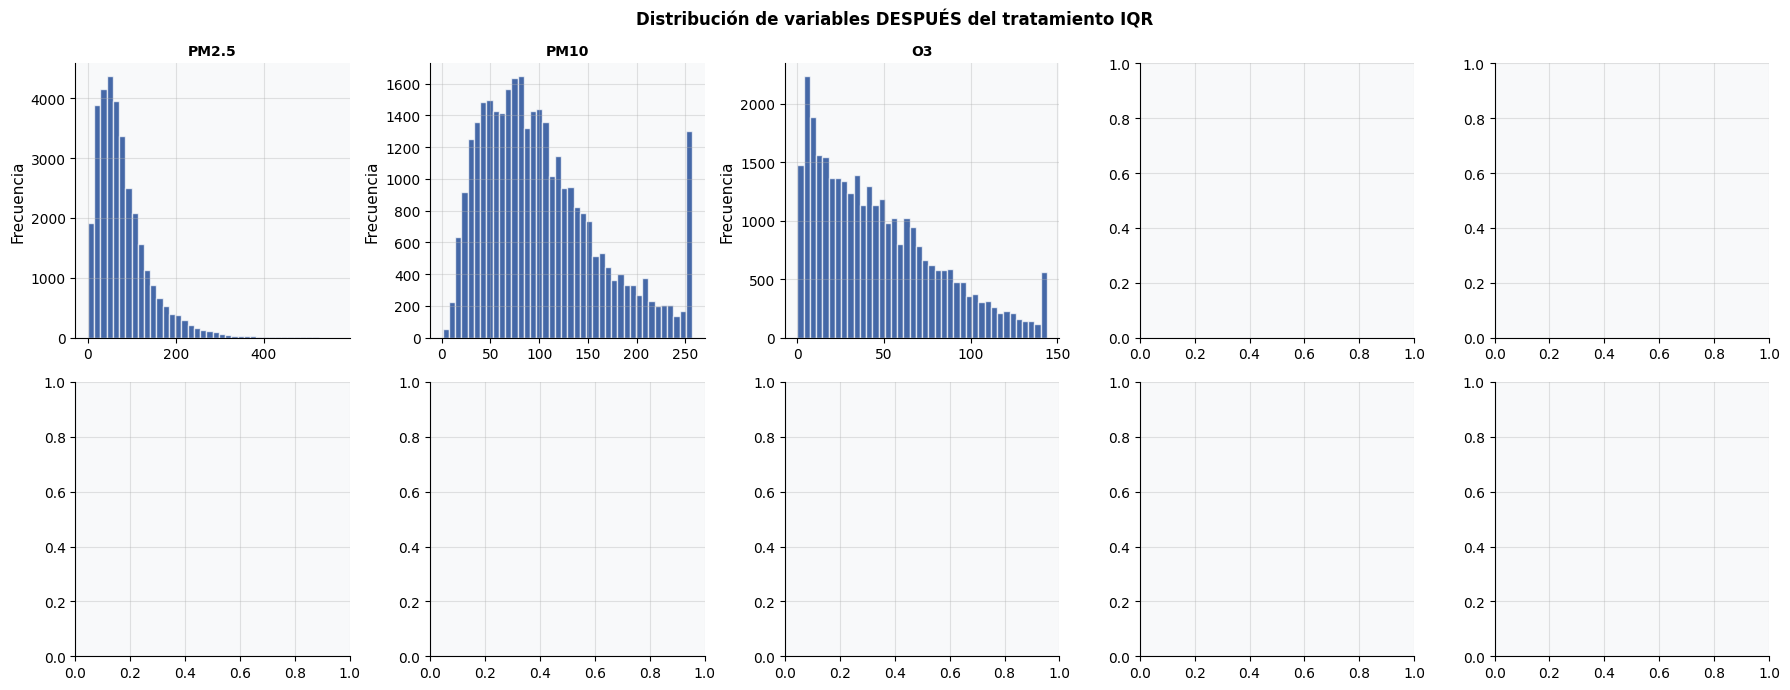

✓ Registros PM2.5 > 150 µg/m³ conservados: 3,647


In [11]:
def iqr_clip(series, protect_high=False, protect_threshold=150):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR_val = Q3 - Q1
    lower = Q1 - 1.5 * IQR_val
    if protect_high:
        out = series.copy()
        out[out < lower] = lower
        return out
    upper = Q3 + 1.5 * IQR_val
    return series.clip(lower=lower, upper=upper)

print('Diagnóstico de anomalías ANTES del tratamiento IQR:')
print('-' * 55)
for col in NUMERIC_COLS:
    Q1, Q3 = df_unified[col].quantile(0.25), df_unified[col].quantile(0.75)
    IQR_v = Q3 - Q1
    n_out = ((df_unified[col] < Q1 - 1.5*IQR_v) | (df_unified[col] > Q3 + 1.5*IQR_v)).sum()
    pct = n_out / len(df_unified) * 100
    print(f'  {col:<8} IQR=[{Q1:.1f}, {Q3:.1f}]  outliers: {n_out:,} ({pct:.1f}%)')

for col in NUMERIC_COLS:
    protect = (col == 'PM2.5')
    df_unified[col] = iqr_clip(df_unified[col], protect_high=protect, protect_threshold=150)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Distribución de variables DESPUÉS del tratamiento IQR', fontweight='bold')
for ax, col in zip(axes.flatten(), NUMERIC_COLS):
    ax.hist(df_unified[col].dropna(), bins=40, color='#003087', alpha=0.72, edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('grafico_vc_histogramas_iqr.png', dpi=130, bbox_inches='tight')
plt.show()
pm25_crit = (df_unified['PM2.5'] > 150).sum()
print(f'✓ Registros PM2.5 > 150 µg/m³ conservados: {pm25_crit:,}')


#### VC-7 — Ingeniería de características: Codificación algebraica de variables categóricas
`wd` (dirección de viento) y `region` → valores numéricos (Label Encoding).

In [12]:
le_wd      = LabelEncoder()
le_station = LabelEncoder()

if 'wd' in df_unified.columns:
    df_unified['wd'] = df_unified['wd'].astype(str).fillna('unknown')
    df_unified['wd_enc'] = le_wd.fit_transform(df_unified['wd'])
    print('Categorías wd →', list(enumerate(le_wd.classes_)))
else:
    df_unified['wd_enc'] = 0
    print('⚠ Columna wd no encontrada; wd_enc = 0')

df_unified['station_enc'] = le_station.fit_transform(df_unified['region'].astype(str))
print('\nCategorías station →')
for i, name in enumerate(le_station.classes_):
    print(f'  {i:2d} = {name}')
print(f'\n✓ Columnas creadas: wd_enc, station_enc')


⚠ Columna wd no encontrada; wd_enc = 0

Categorías station →
   0 = Aotizhongxin
   1 = Changping
   2 = Dingling
   3 = Dongsi
   4 = Guanyuan
   5 = Gucheng
   6 = Huairou
   7 = Nongzhanguan
   8 = Shunyi
   9 = Tiantan
  10 = Wanliu
  11 = Wanshouxigong

✓ Columnas creadas: wd_enc, station_enc


#### VC-8 — Variables de lag y promedios móviles (autocorrelación temporal)
Capturan la **persistencia temporal del smog**: un día de alta contaminación predice el siguiente.

In [13]:
df_unified = df_unified.sort_values(['region', 'datetime']).reset_index(drop=True)

df_unified['PM25_lag1'] = (
    df_unified.groupby('region')['PM2.5']
    .transform(lambda x: x.shift(1))
)
df_unified['PM25_lag7'] = (
    df_unified.groupby('region')['PM2.5']
    .transform(lambda x: x.shift(7))
)
df_unified['PM25_ma7'] = (
    df_unified.groupby('region')['PM2.5']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)
df_unified['PM25_ma30'] = (
    df_unified.groupby('region')['PM2.5']
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)

for col in ['PM25_lag1', 'PM25_lag7', 'PM25_ma7', 'PM25_ma30']:
    df_unified[col] = (
        df_unified.groupby('region')[col]
        .transform(lambda x: x.bfill().ffill())
    )

print('✓ Variables temporales agregadas:')
print('  PM25_lag1  — PM2.5 del día anterior')
print('  PM25_lag7  — PM2.5 de hace 7 días')
print('  PM25_ma7   — Promedio móvil 7 días')
print('  PM25_ma30  — Promedio móvil 30 días')
print(f'\nNulos en variables de lag:')
print(df_unified[['PM25_lag1','PM25_lag7','PM25_ma7','PM25_ma30']].isnull().sum().to_string())


✓ Variables temporales agregadas:
  PM25_lag1  — PM2.5 del día anterior
  PM25_lag7  — PM2.5 de hace 7 días
  PM25_ma7   — Promedio móvil 7 días
  PM25_ma30  — Promedio móvil 30 días

Nulos en variables de lag:
PM25_lag1    0
PM25_lag7    0
PM25_ma7     0
PM25_ma30    0


#### VC-9 — Normalización Min-Max [0, 1]
Indispensable para que variables de gran escala (Presión ~1010 hPa) no anulen a las pequeñas (O3 ~50 µg/m³) en los cálculos de distancia KNN.

In [14]:
COLS_TO_NORMALIZE = (NUMERIC_COLS
                     + ['wd_enc', 'station_enc',
                        'PM25_lag1', 'PM25_lag7',
                        'PM25_ma7', 'PM25_ma30'])
COLS_TO_NORMALIZE = [c for c in COLS_TO_NORMALIZE if c in df_unified.columns]

scaler_mm = MinMaxScaler()
df_normalized = df_unified.copy()
df_normalized[COLS_TO_NORMALIZE] = scaler_mm.fit_transform(
    df_unified[COLS_TO_NORMALIZE].fillna(0)
)

print('✓ Normalización Min-Max aplicada a:')
for col in COLS_TO_NORMALIZE:
    mn = df_normalized[col].min()
    mx = df_normalized[col].max()
    print(f'  {col:<15} min={mn:.4f}  max={mx:.4f}')


✓ Normalización Min-Max aplicada a:
  PM2.5           min=0.0000  max=1.0000
  PM10            min=0.0000  max=1.0000
  O3              min=0.0000  max=1.0000
  wd_enc          min=0.0000  max=0.0000
  station_enc     min=0.0000  max=1.0000
  PM25_lag1       min=0.0000  max=1.0000
  PM25_lag7       min=0.0000  max=1.0000
  PM25_ma7        min=0.0000  max=1.0000
  PM25_ma30       min=0.0000  max=1.0000


#### VC-10 — DataFrame final: `vector_caracteristicas_unificado`
Puramente numérico, sin nulos, normalizado. Listo para ingresar a modelos de reducción de dimensionalidad (PCA) o visualización interactiva KNN.

In [15]:
FEATURE_COLS_FINAL = list(dict.fromkeys(
    COLS_TO_NORMALIZE
    + ([c for c in ['month', 'year'] if c in df_normalized.columns])
))

ID_COLS = [c for c in ['datetime', 'region', 'period', 'zona']
           if c in df_normalized.columns]

vector_caracteristicas_unificado = (
    df_normalized[ID_COLS + FEATURE_COLS_FINAL]
    .dropna(subset=FEATURE_COLS_FINAL)
    .reset_index(drop=True)
)

print('=' * 62)
print('  VECTOR DE CARACTERÍSTICAS UNIFICADO — Resumen')
print('=' * 62)
print(f'  Registros totales : {len(vector_caracteristicas_unificado):,}')
print(f'  Características   : {len(FEATURE_COLS_FINAL)}')
print(f'  Nulos totales     : '
      f'{vector_caracteristicas_unificado[FEATURE_COLS_FINAL].isnull().sum().sum()}')
print(f'  Períodos          : {sorted(vector_caracteristicas_unificado["period"].unique())}')
print(f'  Estaciones        : {vector_caracteristicas_unificado["region"].nunique()}')
print(f'  Rango             : '
      f'{vector_caracteristicas_unificado["datetime"].min().date()} → '
      f'{vector_caracteristicas_unificado["datetime"].max().date()}')
print('-' * 62)
print('  Características incluidas:')
for c in FEATURE_COLS_FINAL:
    print(f'    • {c}')
print('=' * 62)
vector_caracteristicas_unificado[FEATURE_COLS_FINAL].describe().round(4)


  VECTOR DE CARACTERÍSTICAS UNIFICADO — Resumen
  Registros totales : 33,060
  Características   : 11
  Nulos totales     : 0
  Períodos          : ['2013-2017', '2022-2026']
  Estaciones        : 12
  Rango             : 2013-03-01 → 2026-02-17
--------------------------------------------------------------
  Características incluidas:
    • PM2.5
    • PM10
    • O3
    • wd_enc
    • station_enc
    • PM25_lag1
    • PM25_lag7
    • PM25_ma7
    • PM25_ma30
    • month
    • year


,PM2.5,PM10,O3,wd_enc,station_enc,PM25_lag1,PM25_lag7,PM25_ma7,PM25_ma30,month,year
count,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00,33060.00
mean,0.14,0.40,0.32,0.00,0.50,0.14,0.14,0.22,0.39,6.62,2018.97
std,0.11,0.24,0.25,0.00,0.31,0.11,0.11,0.11,0.13,3.50,4.72
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2013.00
25%,0.06,0.21,0.12,0.00,0.25,0.06,0.06,0.14,0.29,4.00,2015.00
50%,0.11,0.35,0.28,0.00,0.50,0.11,0.11,0.19,0.37,7.00,2016.00
75%,0.18,0.53,0.47,0.00,0.75,0.18,0.18,0.27,0.46,10.00,2024.00
max,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,12.00,2026.00


#### VC-11 — Matriz de Correlación Térmica (Heatmap)
Confirma al **Punto de Rocío (DEW)** como variable raíz y predictor dominante de PM2.5.

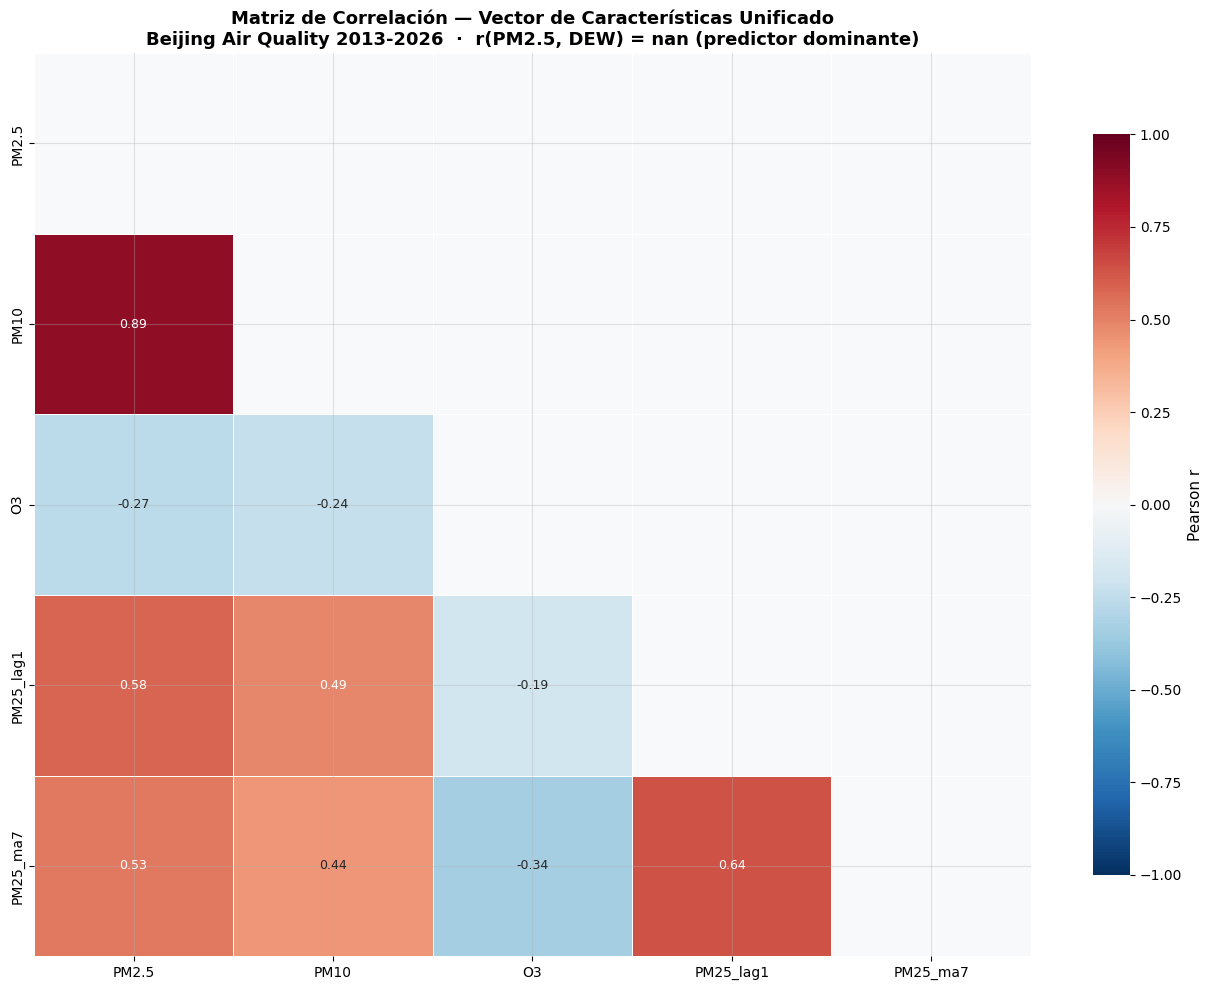

✓ Heatmap de correlación guardado: grafico_vc_correlacion_heatmap.png

Top correlaciones con PM2.5 (|r|):
  PM10            r = +0.889
  PM25_lag1       r = +0.581
  PM25_ma7        r = +0.527
  O3              r = -0.269


In [16]:
CORR_COLS = [c for c in ['PM2.5', 'DEW', 'TEMP', 'PRES', 'WSPM',
                          'PM10', 'SO2', 'NO2', 'CO', 'O3',
                          'PM25_lag1', 'PM25_ma7']
             if c in vector_caracteristicas_unificado.columns]

corr_vc = vector_caracteristicas_unificado[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr_vc, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_vc, ax=ax, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.82}
)

r_dew = corr_vc.loc['PM2.5', 'DEW'] if 'DEW' in CORR_COLS else float('nan')
ax.set_title(
    f'Matriz de Correlación — Vector de Características Unificado\n'
    f'Beijing Air Quality 2013-2026  ·  r(PM2.5, DEW) = {r_dew:.2f} (predictor dominante)',
    fontweight='bold', fontsize=13
)

plt.tight_layout()
plt.savefig('grafico_vc_correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Heatmap de correlación guardado: grafico_vc_correlacion_heatmap.png')

top_corr = corr_vc['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
print('\nTop correlaciones con PM2.5 (|r|):')
for feat, val in top_corr.items():
    dir_r = corr_vc.loc['PM2.5', feat]
    print(f'  {feat:<15} r = {dir_r:+.3f}')


#### VC-12 — Exportar el vector de características a CSV
Archivo de salida listo para PCA, KNN u otros modelos.

In [17]:
output_path = '../datasets/vector_caracteristicas_unificado.csv'
vector_caracteristicas_unificado.to_csv(output_path, index=False)
size_kb = Path(output_path).stat().st_size / 1024
print(f'✓ Exportado: {output_path}')
print(f'  Tamaño: {size_kb:.0f} KB')
print(f'  Filas: {len(vector_caracteristicas_unificado):,}')
print(f'  Columnas: {len(vector_caracteristicas_unificado.columns)}')

print(f'✓ Archivo guardado en: {Path(output_path).resolve()}')


✓ Exportado: ../datasets/vector_caracteristicas_unificado.csv
  Tamaño: 6552 KB
  Filas: 33,060
  Columnas: 15
✓ Archivo guardado en: C:\dev\beijing-air-quality\datasets\vector_caracteristicas_unificado.csv
